#### Importing required libraries

In [32]:
import matplotlib.pyplot as plt 
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
import seaborn as sns
import pandas as pd
import matplotlib.pylab as plt
import numpy as np

#### Loading dataset statistics to get the final time cut 
* **The initial  time cut will be 10 minutes after the first post publication**
*  **The final time cut will be equal to 6 hours after the publication of last post**

In [33]:
df_posts_by_tm = pd.read_csv('ottawa_shooting_posts_by_time_cut.csv')

In [34]:
df_posts_by_tm['new_posts_cum_sum'] = df_posts_by_tm.new_posts.cumsum()

In [35]:
max_time_cut = int(df_posts_by_tm[df_posts_by_tm.new_posts_cum_sum==int(df_posts_by_tm.new_posts_cum_sum.max())]\
                   .time_cut.min())+(60*6)

In [36]:
max_time_cut

959

#### HAN model

In [37]:
experiment = mlflow.get_experiment_by_name('HAN 2025-11-03 Ottawa Shooting')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_han = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")
    
df_han = df_han[df_han['metrics.time_cut']<=max_time_cut]

HAN 2025-11-03 Ottawa Shooting


In [38]:
df_han['metrics.curr_f1'] = 2 * (
    df_han['metrics.curr_precision'] * df_han['metrics.curr_recall']
) / (
    df_han['metrics.curr_precision'] + df_han['metrics.curr_recall']
)

df_han['metrics.final_f1'] = 2 * (
    df_han['metrics.final_precision'] * df_han['metrics.final_recall']
) / (
    df_han['metrics.final_precision'] + df_han['metrics.final_recall']
)



In [39]:
df_han.shape

(94, 21)

### GAT model

In [40]:
experiment = mlflow.get_experiment_by_name('GAT 2025-11-03 Ottawa Shooting')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_gat = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='metrics.time_cut')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")
df_gat = df_gat[df_gat['metrics.time_cut']<=max_time_cut]

GAT 2025-11-03 Ottawa Shooting


In [41]:
df_gat['metrics.curr_f1'] = 2 * (
    df_gat['metrics.curr_precision'] * df_gat['metrics.curr_recall']
) / (
    df_gat['metrics.curr_precision'] + df_gat['metrics.curr_recall']
)

df_gat['metrics.final_f1'] = 2 * (
    df_gat['metrics.final_precision'] * df_gat['metrics.final_recall']
) / (
    df_gat['metrics.final_precision'] + df_gat['metrics.final_recall']
)



In [42]:
df_gat.shape

(94, 21)

#### LSTM model

In [43]:
experiment = mlflow.get_experiment_by_name('LSTM 2025-11-03 Ottawa Shooting')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_lstm = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='metrics.test_recall')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")
df_lstm =df_lstm[df_lstm['metrics.time_cut']<=max_time_cut]

LSTM 2025-11-03 Ottawa Shooting


In [44]:

df_lstm.rename(columns={'metrics.test_precision':'metrics.final_precision',
                        'metrics.test_recall':'metrics.final_recall',
                        'metrics.test_auc':'metrics.final_auc'},inplace=True)

In [45]:
df_lstm['metrics.curr_f1'] = 2 * (
    df_lstm['metrics.curr_precision'] * df_lstm['metrics.curr_recall']
) / (
    df_lstm['metrics.curr_precision'] + df_lstm['metrics.curr_recall']
)

df_lstm['metrics.final_f1'] = 2 * (
    df_lstm['metrics.final_precision'] * df_lstm['metrics.final_recall']
) / (
    df_lstm['metrics.final_precision'] + df_lstm['metrics.final_recall']
)



In [46]:
df_lstm['metrics.new_posts'] =  np.array(df_gat['metrics.new_posts'])

In [47]:
df_lstm.shape

(94, 25)

#### Light GBM model

In [48]:
experiment = mlflow.get_experiment_by_name('LGBM 2025-11-03 Ottawa Shooting')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_lgb = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")
df_lgb = df_lgb[df_lgb['metrics.time_cut']<=max_time_cut]

LGBM 2025-11-03 Ottawa Shooting


In [49]:
df_lgb['metrics.curr_f1'] = 2 * (
    df_lgb['metrics.curr_precision'] * df_lgb['metrics.curr_recall']
) / (
    df_lgb['metrics.curr_precision'] + df_lgb['metrics.curr_recall']
)

df_lgb['metrics.final_f1'] = 2 * (
    df_lgb['metrics.final_precision'] * df_lgb['metrics.final_recall']
) / (
    df_lgb['metrics.final_precision'] + df_lgb['metrics.final_recall']
)



In [50]:
df_lgb.shape

(94, 27)

#### Random Forest model

In [51]:
experiment = mlflow.get_experiment_by_name('Random Forest 2025-11-03 Ottawa Shooting')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_rf = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")
df_rf = df_rf[df_rf['metrics.time_cut']<=max_time_cut]

Random Forest 2025-11-03 Ottawa Shooting


In [52]:
df_rf['metrics.curr_f1'] = 2 * (
    df_rf['metrics.curr_precision'] * df_rf['metrics.curr_recall']
) / (
    df_rf['metrics.curr_precision'] + df_rf['metrics.curr_recall']
)

df_rf['metrics.final_f1'] = 2 * (
    df_rf['metrics.final_precision'] * df_rf['metrics.final_recall']
) / (
    df_rf['metrics.final_precision'] + df_rf['metrics.final_recall']
)



In [53]:
df_rf.shape

(94, 27)

#### Creating Hours column

In [54]:
df_han['time_cut_hours'] = round(df_han['metrics.time_cut']/60,2)
df_gat['time_cut_hours'] = round(df_gat['metrics.time_cut']/60,2)
df_lgb['time_cut_hours'] = round(df_lgb['metrics.time_cut']/60,2)
df_rf['time_cut_hours'] = round(df_rf['metrics.time_cut']/60,2)
df_lstm['time_cut_hours'] = round(df_lstm['metrics.time_cut']/60,2)

#### Creating a single dataframe with all experiments

In [55]:

df_han =df_han.dropna(subset='metrics.time_cut')[['time_cut_hours','metrics.final_recall','metrics.final_auc','metrics.final_precision',\
                 'metrics.final_acc','metrics.curr_precision','metrics.curr_recall','metrics.curr_acc','metrics.new_posts',\
                'metrics.final_f1','metrics.curr_f1','metrics.time_cut']]

df_gat =df_gat.dropna(subset='metrics.time_cut')[['time_cut_hours','metrics.final_recall','metrics.final_auc','metrics.final_precision',\
                 'metrics.final_acc','metrics.curr_precision','metrics.curr_recall','metrics.curr_acc','metrics.new_posts','metrics.time_cut',\
                  'metrics.final_f1','metrics.curr_f1']]


df_lgb =df_lgb.dropna(subset='metrics.time_cut')[['time_cut_hours','metrics.final_recall','metrics.final_auc','metrics.final_precision',\
                 'metrics.final_acc','metrics.curr_precision','metrics.curr_recall','metrics.curr_acc','metrics.new_posts',\
                 'metrics.final_f1','metrics.curr_f1','metrics.time_cut']]

df_rf =df_rf.dropna(subset='metrics.time_cut')[['time_cut_hours','metrics.final_recall','metrics.final_auc','metrics.final_precision',\
                 'metrics.final_acc','metrics.curr_precision','metrics.curr_recall','metrics.curr_acc','metrics.new_posts','metrics.time_cut',\
                 'metrics.final_f1','metrics.curr_f1']]


df_lstm.rename(columns={'metrics.test_precision':'metrics.final_precision',
                        'metrics.test_recall':'metrics.final_recall',
                        'metrics.test_auc':'metrics.final_auc'},inplace=True)

df_lstm =df_lstm.dropna(subset='metrics.time_cut')[['time_cut_hours','metrics.final_recall','metrics.final_auc','metrics.final_precision',\
               'metrics.new_posts','metrics.curr_precision','metrics.curr_recall','metrics.curr_acc','metrics.time_cut','metrics.final_f1','metrics.curr_f1']]

df_rf['model'] ='Random Forest'

df_lstm['model'] ='LSTM'


df_han['model'] ='HAN'
df_gat['model'] ='GAT'
df_lgb['model'] ='Light Gbm'


In [56]:
df_rf.fillna(0,inplace=True)
df_han.fillna(0,inplace=True)
df_gat.fillna(0,inplace=True)
df_lgb.fillna(0,inplace=True)
df_lstm.fillna(0,inplace=True)

In [57]:
df_all = pd.concat([df_rf,df_han,df_gat,df_lgb,df_lstm])

In [58]:
df_all =df_all.merge(df_posts_by_tm[['new_posts',\
                                     'rumours', 'no_rumours','time_cut','new_posts_cum_sum']],how='inner',right_on='time_cut', left_on='metrics.time_cut')

#### Final metrics by model

In [59]:
df_all.groupby('model')[['metrics.final_recall', 'metrics.final_precision','metrics.final_auc','metrics.final_f1']]\
                        .agg(['mean']).round(2).sort_values(('metrics.final_f1', 'mean'), ascending=False)


,metrics.final_recall,metrics.final_precision,metrics.final_auc,metrics.final_f1
,mean,mean,mean,mean
model,,,,
HAN,0.79,0.79,0.86,0.79
GAT,0.77,0.77,0.85,0.77
LSTM,0.74,0.79,0.85,0.76
Light Gbm,0.68,0.86,0.84,0.76
Random Forest,0.70,0.84,0.84,0.76


#### Precision and recall by hour and model
Measuring detection through time

In [60]:
df_all.sort_values(by=['model','metrics.time_cut'],inplace=True)

In [61]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Filter only even time_cuts (optional)
df_all = df_all[df_all['metrics.time_cut'] % 4 == 0]

# Create the subplot
fig = make_subplots(
    rows=1, cols=1,
    subplot_titles=["Time vs. Final Precision with Number of Posts"],
    specs=[[{"secondary_y": True}]]
)

# Define colors
colors = ['red', 'orange', 'green', 'purple', 'blue', 'brown'] 

# Add traces by model
for i, model in enumerate(df_all['model'].unique()):
    df_model = df_all[df_all['model'] == model]
    color = colors[i % len(colors)]

    # Final Precision (left Y-axis)
    fig.add_trace(
        go.Scatter(
            x=df_model['time_cut_hours'],
            y=df_model['metrics.final_precision'],
            mode='lines+markers',
            name=f'{model}',
            line=dict(color=color)
        ),
        row=1, col=1, secondary_y=False
    )


# Add traces by model
for i, model in enumerate(df_all['model'].unique()):
    if model=='GAT':
        df_model = df_all[df_all['model'] == model]
        fig.add_trace(
            go.Scatter(
                x=df_model['time_cut_hours'],
                y=df_model['new_posts_cum_sum'],
                mode='lines',
                name='Cumulative Posts',
                line=dict(color='gray', dash='solid'),
                opacity=0.7
            ),
            row=1, col=1, secondary_y=True
        )
    
    # Update layout, axes, etc. as before
    # ...





# Update layout
fig.update_layout(
    title="Final Precision by Model with Number of Posts",
    title_x=0.5,
    template='plotly_white',
    width=1100,
    height=450,
    font=dict(size=14),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.3,
        xanchor="center",
        x=0.5,
        font=dict(size=14)
    )
)

# Axis titles
fig.update_xaxes(title_text="Time (hours)")
fig.update_yaxes(title_text="Final Precision", range=[0, 1], secondary_y=False)
fig.update_yaxes(title_text="Number of Posts", secondary_y=True)

fig.show()


In [62]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Filter only even time_cuts (optional)
# df_all = df_all[df_all['metrics.time_cut'] % 4 == 0]

# Create the subplot
fig = make_subplots(
    rows=1, cols=1,
    subplot_titles=["Time vs. Final Recall with Number of Posts"],
    specs=[[{"secondary_y": True}]]
)

# Define colors
colors = ['red', 'orange', 'green', 'purple', 'blue', 'brown'] 
# Add traces by model
for i, model in enumerate(df_all['model'].unique()):
    df_model = df_all[df_all['model'] == model]
    color = colors[i % len(colors)]

    # Final Recall (left Y-axis)
    fig.add_trace(
        go.Scatter(
            x=df_model['time_cut_hours'],
            y=df_model['metrics.final_recall'],
            mode='lines+markers',
            name=f'{model}',
            line=dict(color=color)
        ),
        row=1, col=1, secondary_y=False
    )


# Add traces by model
for i, model in enumerate(df_all['model'].unique()):
    if model=='GAT':
        df_model = df_all[df_all['model'] == model]
        fig.add_trace(
            go.Scatter(
                x=df_model['time_cut_hours'],
                y=df_model['new_posts_cum_sum'],
                mode='lines',
                name='Cumulative Posts',
                line=dict(color='gray', dash='solid'),
                opacity=0.7
            ),
            row=1, col=1, secondary_y=True
        )
    
    # Update layout, axes, etc. as before
    # ...

# Update layout
fig.update_layout(
    title="Final Recall by Model with Number of Posts",
    title_x=0.5,
    template='plotly_white',
    width=1100,
    height=450,
    font=dict(size=14),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.3,
        xanchor="center",
        x=0.5,
        font=dict(size=14)
    )
)

# Axis titles
fig.update_xaxes(title_text="Time (hours)")
fig.update_yaxes(title_text="Final Recall", range=[0, 1], secondary_y=False)
fig.update_yaxes(title_text="Number of Posts", secondary_y=True)

fig.show()


#### Metrics at the t0 (time of post publication)
Measuring early detection

In [63]:
df_all[df_all['metrics.new_posts'] > 0] \
    .groupby('model')[['metrics.curr_recall', 'metrics.curr_precision', 'metrics.curr_f1']] \
    .agg(['mean']) \
    .round(2) \
    .sort_values(('metrics.curr_f1', 'mean'), ascending=False)


,metrics.curr_recall,metrics.curr_precision,metrics.curr_f1
,mean,mean,mean
model,,,
HAN,0.85,0.83,0.84
GAT,0.76,0.75,0.75
Random Forest,0.79,0.76,0.75
LSTM,0.72,0.65,0.64
Light Gbm,0.64,0.65,0.62


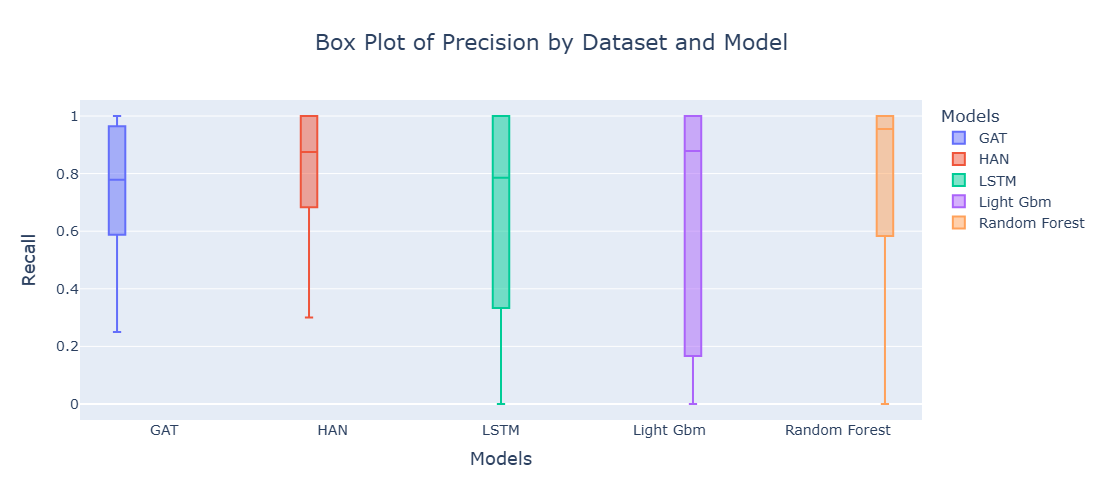

In [64]:
import plotly.express as px

# Create a Plotly figure for each dataset
fig = px.box(
    df_all[df_all['metrics.new_posts']>0],
    x='model',
    y='metrics.curr_precision',
    color='model',
    boxmode='group',
    title="Box Plot of Precision by Dataset and Model",
    labels={'metrics.curr_precision': 'Precision', 'model': 'Model'}
)

# Update layout for better visualization and readability
fig.update_layout(
    title="Box Plot of Precision by Dataset and Model",  
    title_x=0.5,  
    width=800,  
    height=500,  
    font=dict(size=16),  
    xaxis=dict(title="Models", title_font=dict(size=18), tickfont=dict(size=14)),
    yaxis=dict(
        title="Recall", 
        title_font=dict(size=18), 
        tickfont=dict(size=14),
        
    ),
    legend=dict(title="Models", font=dict(size=14))  
)

# Show the plot
fig.show()


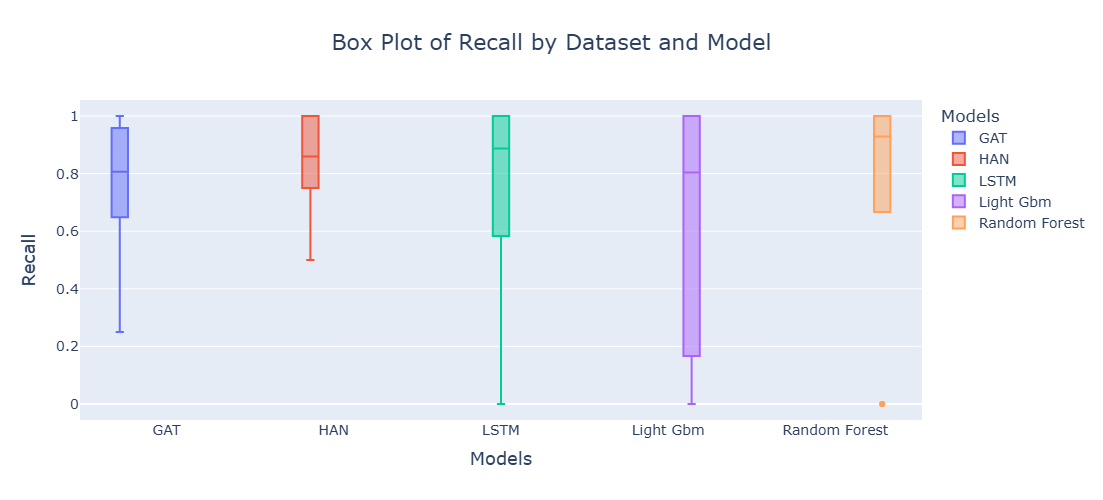

In [65]:
import plotly.express as px

# Create a Plotly figure for each dataset
fig = px.box(
    df_all[df_all['metrics.new_posts']>0],
    x='model',
    y='metrics.curr_recall',
    color='model',
    boxmode='group',
    title="Box Plot of Recall by Dataset and Model",
    labels={'metrics.test_recall': 'Recall', 'model': 'Model'}
)

# Update layout for better visualization and readability
fig.update_layout(
    title="Box Plot of Recall by Dataset and Model",  
    title_x=0.5,  
    width=800,  
    height=500,  
    font=dict(size=16),  
    xaxis=dict(title="Models", title_font=dict(size=18), tickfont=dict(size=14)),
    yaxis=dict(
        title="Recall", 
        title_font=dict(size=18), 
        tickfont=dict(size=14),
        
    ),
    legend=dict(title="Models", font=dict(size=14))  
)

# Show the plot
fig.show()
